<h2>Cardiovascular Disease Prediction - Data Cleaning & Decision Tree Model</h2>
<h3>Manas Borisagar (24010101031)</h3>

<p>
This notebook takes the cardio_train.csv dataset, cleans it up (duplicates, invalid values, outliers),
prepares it for machine learning (normalisation), and then trains a simple <b>Decision Tree Classifier</b>
using scikit-learn to predict the <b>cardio</b> label (0 = No disease, 1 = Has disease).
</p>

<p>
At the end, the trained model is saved to disk as <code>model.pkl</code> using <code>joblib</code>.
</p>

### 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

### 2. Loading the Dataset

The file uses `;` as a separator instead of the usual comma.

In [2]:
df = pd.read_csv("cardio_train.csv", sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
df.shape

(70000, 13)

### 3. Basic Info & Missing Values

Quick check before cleaning - datatypes, nulls, duplicate rows.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


### 4. Data Cleaning

Looking at `df.describe()`, a few problems show up:

- **age** is given in *days*, which isn't very readable -> convert to years.
- **id** column is just a row identifier, not useful for prediction -> drop it.
- **duplicate rows** -> remove them.
- **ap_hi / ap_lo (blood pressure)** have some negative / unrealistically large values, and some rows where ap_hi (systolic) is lower than ap_lo (diastolic), which is medically not possible -> remove these bad records.
- **height / weight** have some extreme outlier values (e.g. height below 100cm or above 220cm) -> remove these too.

Since this is a fairly large dataset (~70,000 rows), dropping a small percentage of bad rows is safe and won't hurt the model.

In [7]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


**4.1 Convert age from days to years, and drop the id column**

In [8]:
df['age_years'] = (df['age'] / 365).astype(int)
df = df.drop(columns=['id', 'age'])
df.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,156,85.0,140,90,3,1,0,0,1,1,55
2,1,165,64.0,130,70,3,1,0,0,0,1,51
3,2,169,82.0,150,100,1,1,0,0,1,1,48
4,1,156,56.0,100,60,1,1,0,0,0,0,47


**4.2 Remove duplicate rows**

In [9]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f"Removed {before - after} duplicate rows")

Removed 3208 duplicate rows


**4.3 Remove invalid blood pressure records**

Realistic systolic (ap_hi) range: 60-250. Realistic diastolic (ap_lo) range: 40-200. Also ap_hi should always be greater than or equal to ap_lo.

In [10]:
before = df.shape[0]

df = df[(df['ap_hi'] >= 60) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]
df = df[df['ap_hi'] >= df['ap_lo']]

after = df.shape[0]
print(f"Removed {before - after} rows with invalid blood pressure values")

Removed 1324 rows with invalid blood pressure values


**4.4 Remove height/weight outliers**

In [11]:
before = df.shape[0]

df = df[(df['height'] >= 100) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

after = df.shape[0]
print(f"Removed {before - after} rows with unrealistic height/weight")

Removed 33 rows with unrealistic height/weight


In [12]:
print("Final shape after cleaning:", df.shape)
df.describe()

Final shape after cleaning: (65435, 12)


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,65435.000000,65435.000000,65435.000000,65435.000000,65435.000000,65435.000000,65435.000000,65435.000000,65435.000000,65435.000000,65435.000000,65435.000000
mean,1.355345,164.378544,74.437853,126.989394,81.389654,1.380775,1.235608,0.092030,0.055903,0.798044,0.506961,52.848002
std,0.478621,8.095600,14.495626,16.997229,9.644115,0.688997,0.581640,0.289071,0.229736,0.401463,0.499955,6.806910
min,1.000000,100.000000,30.000000,60.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000
25%,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000
50%,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,53.000000
75%,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000
max,2.000000,207.000000,200.000000,240.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.000000


**4.5 Boxplot after cleaning** (compare with the one before cleaning if you want to see the difference)

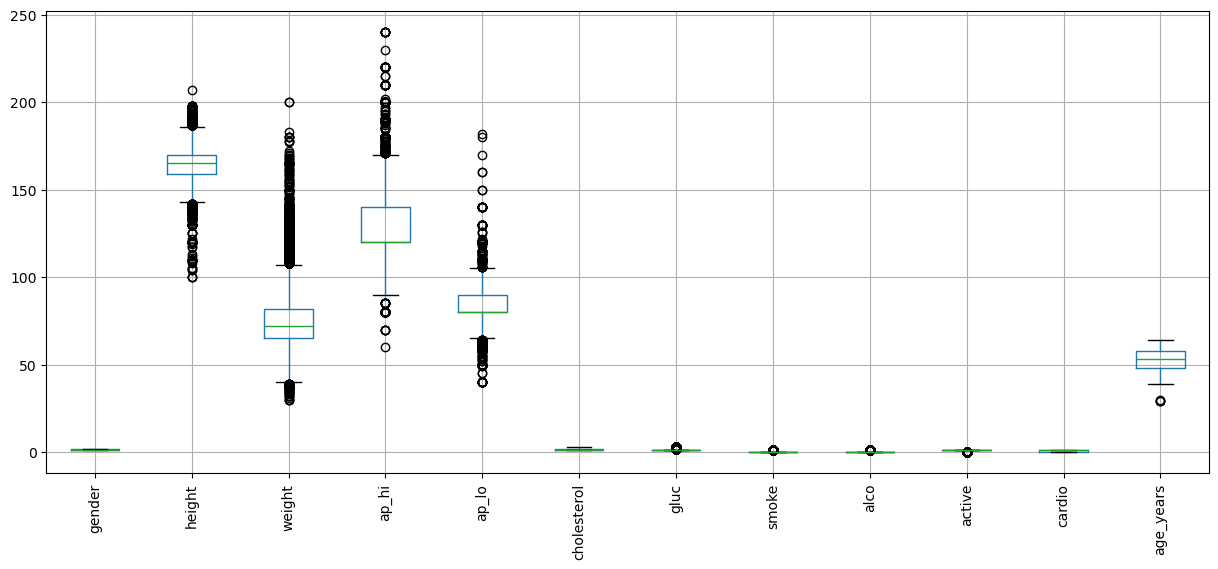

In [13]:
plt.figure(figsize=(15,6))
df.boxplot()
plt.xticks(rotation=90)
plt.show()

### 5. Preparing Data for the Model

- Split the data into features (`X`) and target label (`y`, the `cardio` column).
- Split into training and testing sets (80/20).
- Normalise the features using `StandardScaler` so all columns are on a similar scale.

In [14]:
X = df.drop(columns=['cardio'])
y = df['cardio']

X.shape, y.shape

((65435, 11), (65435,))

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (52348, 11)
Test size: (13087, 11)


**5.1 Normalising the features**

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 6. Training the Decision Tree Model

Using scikit-learn's `DecisionTreeClassifier`. `max_depth` is limited to keep the tree simple and
avoid overfitting (a fully-grown tree tends to memorise the training data).

In [17]:
model = DecisionTreeClassifier(max_depth=6, random_state=42)
model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

### 7. Evaluating the Model

In [18]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7249178574157561


Confusion Matrix:
[[4979 1473]
 [2127 4508]]


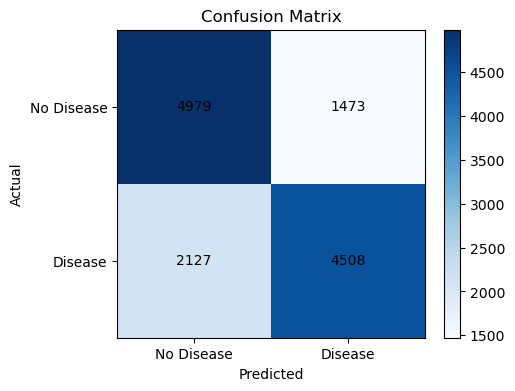

In [19]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ['No Disease','Disease'])
plt.yticks([0,1], ['No Disease','Disease'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar()
plt.show()

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.77      0.73      6452
           1       0.75      0.68      0.71      6635

    accuracy                           0.72     13087
   macro avg       0.73      0.73      0.72     13087
weighted avg       0.73      0.72      0.72     13087



**7.1 Feature importance**

Which features the tree found most useful for splitting.

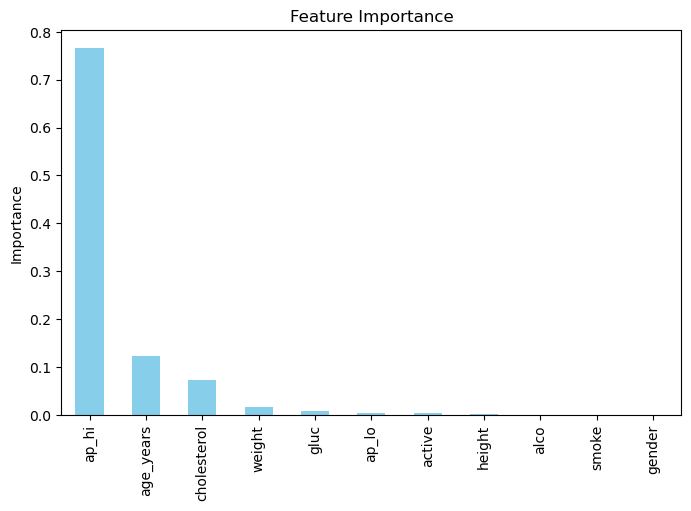

ap_hi          0.765287
age_years      0.123686
cholesterol    0.072526
weight         0.016708
gluc           0.008356
ap_lo          0.005045
active         0.004614
height         0.002023
alco           0.000928
smoke          0.000585
gender         0.000243
dtype: float64

In [21]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind='bar', color='skyblue')
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

importance

**7.2 Visualising the tree (top few levels)**

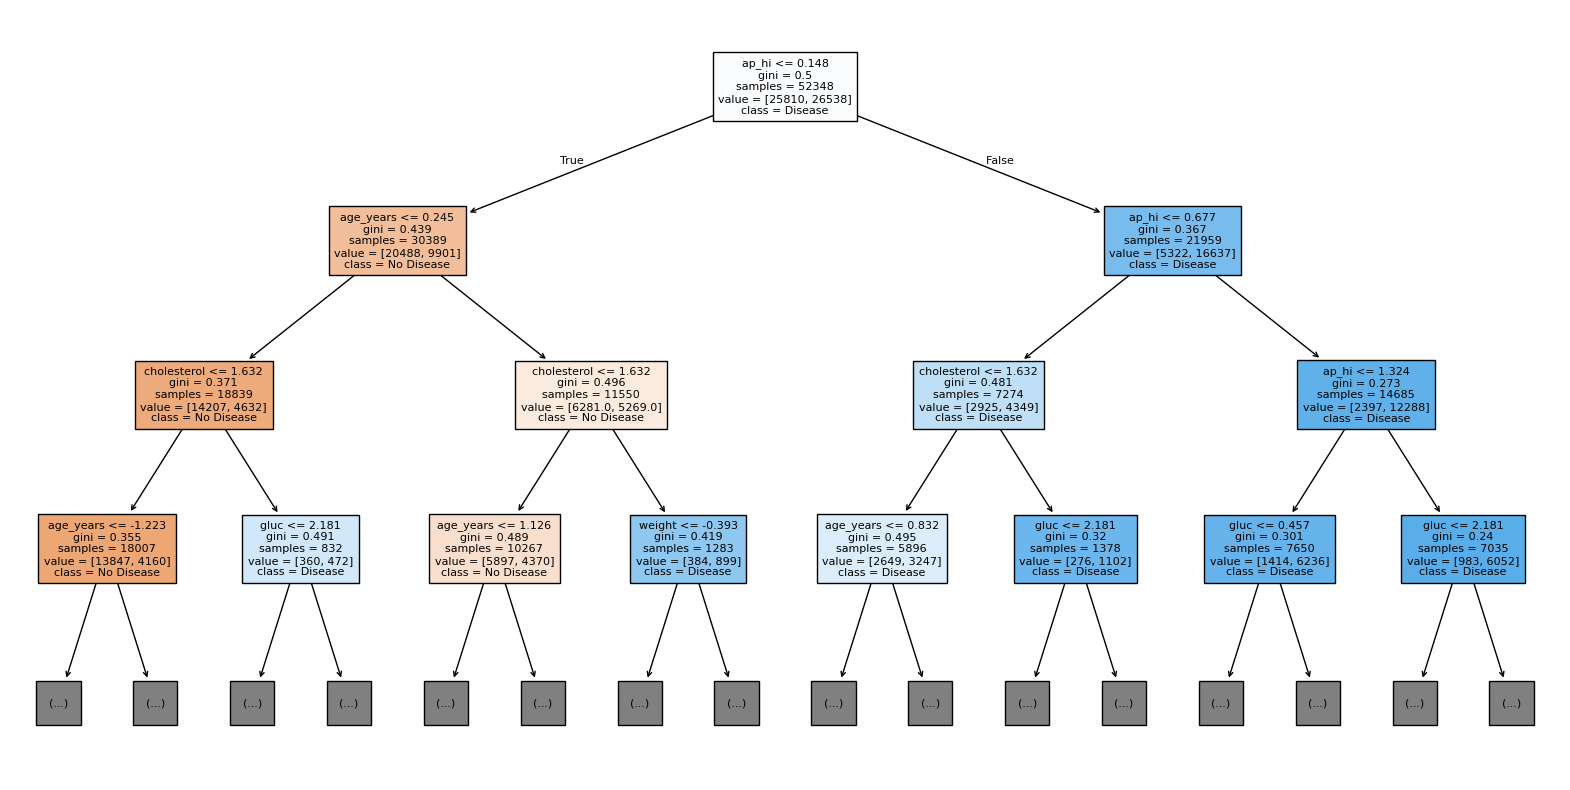

In [22]:
plt.figure(figsize=(20,10))
plot_tree(model, max_depth=3, feature_names=X.columns, class_names=['No Disease','Disease'], filled=True, fontsize=8)
plt.show()

### 8. Saving the Model to Disk

Saving both the trained model and the scaler using `joblib`, so the same preprocessing
can be reused later when making predictions on new data.

In [26]:
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved as model.pkl")
print("Scaler saved as scaler.pkl")

Model saved as model.pkl
Scaler saved as scaler.pkl


**8.1 Quick check - loading the saved model back and testing it**

In [27]:
loaded_model = joblib.load("model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

sample = X_test.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample_scaled)
print("Predicted class:", prediction[0])
print("Actual class:", y_test.iloc[0])

Predicted class: 0
Actual class: 1
